# 01 — Intrinsic population simulation

In this notebook we simulate the **intrinsic binary-neutron-star population**.

Here “intrinsic” means the population that exists in the Universe before any detector selection effect is applied. We are not yet asking whether an event is detectable. We are only drawing the physical parameters of binaries from a chosen population model.

The output of this notebook will be a set of simulated binaries with

$$
(m_1,m_2,z,d_L,\Lambda_1,\Lambda_2,\tilde{\Lambda}) .
$$

These simulated binaries will be used later to construct mock detections and mock single-event parameter-estimation samples.

## What this notebook does

1. Load the polynomial surrogate for the EOS relation $\Lambda_{\rm EOS}(m)$ produced in notebook 00.

2. Draw source-frame component masses from a simple smoothed-box distribution.

3. Draw redshifts from a merger-rate model in an expanding Universe.

4. Assign tidal deformabilities using the EOS relation,

$$
\Lambda_1 = \Lambda_{\rm EOS}(m_1),
\qquad
\Lambda_2 = \Lambda_{\rm EOS}(m_2).
$$

5. Compute detector-frame masses and the binary tidal parameter $\tilde{\Lambda}$.

6. Save the simulated intrinsic population for the next notebooks.

## Important conceptual point

The population model is not just a distribution for masses and redshifts. For neutron stars, it also contains an EOS assumption. In this notebook the EOS is treated as deterministic: once the mass is known, the tidal deformability is fixed.

Schematically, we write the population distribution as

$$
p_{\rm pop}(\theta | \lambda)
=
p(m_1,m_2 | \lambda)
p(z|\lambda)
\delta\left[
\Lambda_1-\Lambda_{\rm EOS}(m_1;\phi_{\rm EOS})
\right]
\delta\left[
\Lambda_2-\Lambda_{\rm EOS}(m_2;\phi_{\rm EOS})
\right].
$$

Here

$$
\theta = (m_1,m_2,z,\Lambda_1,\Lambda_2,\ldots)
$$

denotes the event-level parameters, while $\lambda$ denotes population-level hyperparameters. The EOS parameters $\phi_{\rm EOS}$ are part of the population model because the same EOS relation is shared by all neutron stars.

In this notebook we fix $\phi_{\rm EOS}$ to the polynomial fit obtained in notebook 00.

## What is not included yet

There is no detector model in this notebook:

- no signal-to-noise ratio;
- no detection threshold;
- no selection effects;
- no mock parameter estimation;
- no posterior samples.

Those ingredients enter in the following notebooks.

## Colab setup

If running on Colab, first clone the repository and enter it. If running locally from the repository root, skip this cell.


In [10]:
# # Run this cell only on Colab.
# from google.colab import drive
# drive.mount('/content/drive')

# %cd /content/drive/MyDrive
# %cd ns-eos-population-tutorial
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ns-eos-population-tutorial
!pwd                       # /content/drive/MyDrive/ns-eos-population-tutorial であること
!ls -la data/processed/    # 00の生成物4つが見えること


Mounted at /content/drive
/content/drive/MyDrive/ns-eos-population-tutorial
/content/drive/MyDrive/ns-eos-population-tutorial
total 27
-rw------- 1 root root 6190 Jul  1 14:51 bsk24_loglambda_polyfit.npz
-rw------- 1 root root 7110 Jul  1 14:51 bsk24_mr_lambda.npz
-rw------- 1 root root 6190 Jul  1 14:51 eos_fit__bsk24_m1p00_2p25_poly5.npz
-rw------- 1 root root 7110 Jul  1 14:51 eos_table__bsk24.npz
-rw------- 1 root root    0 Jul  1 14:51 .gitkeep


## Imports and paths


In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmology

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

processed_dir = project_root / 'data/processed'
figures_dir = project_root / 'figures'

processed_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)


## Load the EOS polynomial fit from notebook 00


Notebook 00 converted a tabulated EOS into a polynomial surrogate for

$$
\log \Lambda_{\rm EOS}(m).
$$

We load that surrogate here because the population simulation needs to assign a tidal deformability to every simulated neutron star.

The function used below is

$$
\Lambda_{\rm EOS}(m)
=
\exp\left[
\sum_{k=0}^{K} a_k m^k
\right],
$$

where the coefficients $a_k$ were fitted in notebook 00.

We work with $\log\Lambda$ rather than $\Lambda$ directly because $\Lambda(m)$ spans several orders of magnitude and decreases very steeply with mass. Fitting in log-space gives a smoother and more stable surrogate.

The mass range of the simulated population is chosen to match the validity range of the EOS fit. This avoids evaluating the polynomial surrogate outside the mass interval where it was calibrated.


In [13]:
eos_fit_filename = 'eos_fit__bsk24_m1p00_2p25_poly5.npz'
eos_fit_path = processed_dir / eos_fit_filename

eos_fit = np.load(eos_fit_path)

fit_min = float(eos_fit['fit_min'])
fit_max = float(eos_fit['fit_max'])
eos_chosen_order = int(eos_fit['chosen_order'])
eos_chosen_coeffs = eos_fit['chosen_coeffs']

eos_tag = str(eos_fit['eos_tag'].item())
eos_base_tag = str(eos_fit['eos_base_tag'].item())
fit_mass_tag = str(eos_fit['fit_mass_tag'].item())

def lambda_of_mass(m):
    return np.exp(np.polyval(eos_chosen_coeffs, m))

print(f'Loaded EOS fit: {eos_fit_path}')
print(f'EOS tag: {eos_tag}')
print(f'EOS polynomial order: {eos_chosen_order}')
print(f'EOS fit interval: {fit_min:.3f} -- {fit_max:.3f} Msun')


Loaded EOS fit: /content/drive/MyDrive/ns-eos-population-tutorial/data/processed/eos_fit__bsk24_m1p00_2p25_poly5.npz
EOS tag: bsk24_m1p00_2p25_poly5
EOS polynomial order: 5
EOS fit interval: 1.000 -- 2.250 Msun


## Simulation choices

This cell sets the main choices for the intrinsic population simulation.

The most important parameters are:

- `n_events`: the number of binaries drawn from the intrinsic population;
- `m_min_true`, `m_max_true`: the allowed source-frame mass interval;
- `z_max`: the maximum redshift used for the population draw;
- `alpha_z`, `beta_z`, `z_p`: parameters controlling the redshift evolution of the merger rate.

The number of simulated binaries is arbitrary but compatible with curren constraints in ~1yr time.

The random seed fixes one reproducible realization of the population. Changing the seed changes the Monte Carlo realization, but not the underlying population model.


In [14]:
# Main choices to modify.
seed = 31031993
n_events = 100_000

# Use the same mass interval as the EOS polynomial fit.
m_min_true = fit_min
m_max_true = fit_max
edge_width_true = 0.005
edge_pdf_value = 1e-10

# Madau-Dickinson-like rate parameters.
z_max = 20.0
alpha_z = 2.7
beta_z = 3.0
z_p = 2.0

def number_tag(x):
    if float(x).is_integer():
        return str(int(x))
    return f'{x:.2f}'.replace('.', 'p')

pop_tag = f'smoothbox_md_z{number_tag(z_max)}_n{n_events}_seed{seed}'

rng = np.random.default_rng(seed)

print(f'Population tag: {pop_tag}')


Population tag: smoothbox_md_z20_n100000_seed31031993


## Mass distribution

We now draw the two component masses.

For this tutorial we use a deliberately simple mass model: each component mass is drawn independently from a smoothed-box distribution. This is a controlled population model that is easy to understand and easy to sample from.

The one-dimensional mass distribution is

$$
p(m)
\propto
\sigma\left(
\frac{m-m_{\min}-w}{s}
\right)
\sigma\left(
\frac{m_{\max}-w-m}{s}
\right),
$$

where

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

is the logistic sigmoid.

The distribution is approximately flat between $m_{\min}$ and $m_{\max}$, but the sharp edges are smoothed over a small width. This avoids discontinuities at the boundaries of the allowed mass interval.

The smoothing scale $s$ is chosen so that the PDF is very small at the endpoints. The parameter `edge_pdf_value` controls how suppressed the PDF is at the boundaries.

We first draw two unordered component masses. Then we sort them so that

$$
m_1 \geq m_2 .
$$

This convention is standard in compact-binary analyses: $m_1$ is the primary mass and $m_2$ is the secondary mass.



In [15]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def mass_pdf(m):
    logit_edge = np.log((1.0 - edge_pdf_value) / edge_pdf_value)
    edge_scale = edge_width_true / logit_edge

    left = sigmoid((m - m_min_true - edge_width_true) / edge_scale)
    right = sigmoid((m_max_true - edge_width_true - m) / edge_scale)

    return left * right

m_grid = np.linspace(m_min_true, m_max_true, 5000)
p_m_grid = mass_pdf(m_grid)
p_m_max = p_m_grid.max()

def draw_masses(n):
    draws = []
    while len(draws) < 2 * n:
        proposal = rng.uniform(m_min_true, m_max_true, size=2 * n)
        accept_prob = mass_pdf(proposal) / p_m_max
        accepted = proposal[rng.uniform(size=proposal.size) < accept_prob]
        draws.extend(accepted.tolist())

    masses = np.array(draws[:2 * n]).reshape(n, 2)
    m1 = np.maximum(masses[:, 0], masses[:, 1])
    m2 = np.minimum(masses[:, 0], masses[:, 1])
    return m1, m2

m1, m2 = draw_masses(n_events)

print(f'm1 range: {m1.min():.3f} -- {m1.max():.3f} Msun')
print(f'm2 range: {m2.min():.3f} -- {m2.max():.3f} Msun')


m1 range: 1.008 -- 2.246 Msun
m2 range: 1.004 -- 2.240 Msun


The mass samples are generated by rejection sampling.

The idea is simple:

1. Propose masses uniformly in the allowed interval.

2. Accept each proposed mass with probability proportional to the target PDF.

3. Repeat until we have enough accepted samples.

This is possible here because the smoothed-box PDF is bounded and cheap to evaluate.

The diagnostic plot below will compare the histogram of the simulated masses with the analytic mass PDF. Agreement between the two is a basic check that the sampler is doing what we intended.

## Redshift distribution

We now draw the cosmological redshift of each binary.

The redshift distribution is proportional to the expected number of mergers observed in a redshift shell of the Universe before detector selection effects are applied.

We use

$$
p(z)
\propto
\frac{R(z)}{1+z}
\frac{dV_c}{dz}.
$$

Each factor has a distinct meaning:

- $dV_c/dz$ is the differential comoving volume. It accounts for the fact that there is more volume at larger distances.

- $R(z)$ is the source-frame merger-rate density. It describes how the astrophysical merger rate evolves with redshift.

- The factor $1/(1+z)$ converts source-frame time to detector-frame time. Clocks at redshift $z$ are time-dilated by a factor $1+z$.

For the merger-rate evolution we use a Madau-Dickinson-like form,

$$
R(z)
\propto
\frac{(1+z)^{\alpha_z}}
{
1+\left[
\frac{1+z}{1+z_p}
\right]^{\alpha_z+\beta_z}
}.
$$

This form rises at low redshift, turns over around a characteristic redshift controlled by $z_p$, and decreases at high redshift. It is a convenient phenomenological model inspired by the cosmic star-formation history.

After drawing $z$, we compute the luminosity distance using the chosen cosmology,

$$
d_L = d_L(z).
$$

In this tutorial we use the Planck18 cosmology from `astropy`.

In [16]:
def merger_rate_density(z):
    numerator = (1.0 + z) ** alpha_z
    denominator = 1.0 + ((1.0 + z) / (1.0 + z_p)) ** (alpha_z + beta_z)
    return numerator / denominator

def redshift_pdf_unnormalized(z):
    dvc_dz = cosmology.differential_comoving_volume(z).value
    return merger_rate_density(z) * dvc_dz / (1.0 + z)

z_grid = np.linspace(0.0, z_max, 5000)
p_z_grid = redshift_pdf_unnormalized(z_grid)
p_z_max = p_z_grid.max()

def draw_redshifts(n):
    draws = []
    while len(draws) < n:
        proposal = rng.uniform(0.0, z_max, size=n)
        accept_prob = redshift_pdf_unnormalized(proposal) / p_z_max
        accepted = proposal[rng.uniform(size=proposal.size) < accept_prob]
        draws.extend(accepted.tolist())
    return np.array(draws[:n])

z = draw_redshifts(n_events)
d_l = cosmology.luminosity_distance(z).value

print(f'z range: {z.min():.4f} -- {z.max():.4f}')
print(f'd_L range: {d_l.min():.2f} -- {d_l.max():.2f} Mpc')


z range: 0.0489 -- 19.9568
d_L range: 224.54 -- 229541.16 Mpc


## Derived quantities


We now compute quantities that are determined by the simulated source parameters.

### Detector-frame masses

The source-frame masses are the physical masses of the binary components. The detector measures redshifted masses,

$$
m_{1}^{\rm det} = (1+z)m_1,
\qquad
m_{2}^{\rm det} = (1+z)m_2.
$$

This is the usual mass-redshift degeneracy of gravitational-wave observations: at the waveform level, cosmological redshift stretches the time and frequency scales in the same way as increasing the masses.

### Tidal deformabilities

The tidal deformabilities are assigned using the EOS relation loaded from notebook 00,

$$
\Lambda_1 = \Lambda_{\rm EOS}(m_1),
\qquad
\Lambda_2 = \Lambda_{\rm EOS}(m_2).
$$

We evaluate the EOS relation at the source-frame masses, not the detector-frame masses, because the EOS is a physical relation between the local neutron-star mass and its internal structure.

### Binary tidal parameter

The leading tidal contribution to the waveform phase depends mostly on the mass-weighted combination

$$
\tilde{\Lambda}
=
\frac{16}{13}
\frac{
(m_1+12m_2)m_1^4\Lambda_1
+
(m_2+12m_1)m_2^4\Lambda_2
}
{(m_1+m_2)^5}.
$$

This is the quantity most directly constrained by a single binary-neutron-star inspiral at leading tidal order.

The output of this cell is therefore a physically consistent population: masses, redshifts, distances, and tidal deformabilities all follow from one specified population model and one specified EOS curve.

In [17]:
m1_det = m1 * (1.0 + z)
m2_det = m2 * (1.0 + z)

lambda1 = lambda_of_mass(m1)
lambda2 = lambda_of_mass(m2)

lambda_tilde = (16.0 / 13.0) * (
    (m1 + 12.0 * m2) * m1**4 * lambda1
    + (m2 + 12.0 * m1) * m2**4 * lambda2
) / (m1 + m2) ** 5

print(f'Lambda_1 range: {lambda1.min():.2f} -- {lambda1.max():.2f}')
print(f'Lambda_2 range: {lambda2.min():.2f} -- {lambda2.max():.2f}')
print(f'tilde Lambda range: {lambda_tilde.min():.2f} -- {lambda_tilde.max():.2f}')


Lambda_1 range: 9.05 -- 3199.43
Lambda_2 range: 9.45 -- 3272.68
tilde Lambda range: 9.38 -- 3211.44


## Diagnostic plots


The following plots check that the simulated population has the intended properties.

The first panel shows the source-frame component-mass distribution. The histogram contains the simulated masses, while the solid line shows the target analytic PDF.

The second panel shows the redshift distribution. Again, the histogram shows the Monte Carlo draws and the solid line shows the target PDF.

The third panel shows the EOS assignment. Each simulated component mass is mapped to a tidal deformability through the same EOS curve,

$$
\Lambda = \Lambda_{\rm EOS}(m).
$$




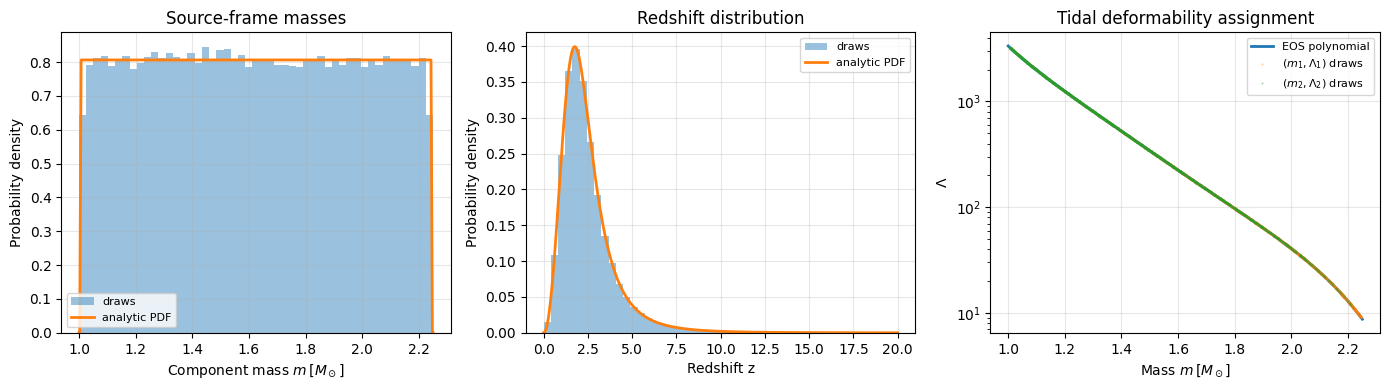

Saved figure to /content/drive/MyDrive/ns-eos-population-tutorial/figures/intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.0))

ax = axes[0]
bins_m = np.linspace(m_min_true, m_max_true, 50)
ax.hist(np.concatenate([m1, m2]), bins=bins_m, density=True, alpha=0.45, label='draws')

m_plot = np.linspace(m_min_true, m_max_true, 500)
p_m_plot = mass_pdf(m_plot)
p_m_plot /= np.trapezoid(p_m_plot, m_plot)
ax.plot(m_plot, p_m_plot, lw=2.0, label='analytic PDF')
ax.set_xlabel(r'Component mass $m\,[M_\odot]$')
ax.set_ylabel('Probability density')
ax.set_title('Source-frame masses')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
bins_z = np.linspace(0.0, z_max, 50)
ax.hist(z, bins=bins_z, density=True, alpha=0.45, label='draws')

p_z_plot = redshift_pdf_unnormalized(z_grid)
p_z_plot /= np.trapezoid(p_z_plot, z_grid)
ax.plot(z_grid, p_z_plot, lw=2.0, label='analytic PDF')
ax.set_xlabel('Redshift z')
ax.set_ylabel('Probability density')
ax.set_title('Redshift distribution')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[2]
m_eos = np.linspace(m_min_true, m_max_true, 500)
ax.plot(m_eos, lambda_of_mass(m_eos), lw=2.0, label='EOS polynomial')
ax.plot(m1[:3000], lambda1[:3000], '.', ms=1.5, alpha=0.25, label=r'$(m_1,\Lambda_1)$ draws')
ax.plot(m2[:3000], lambda2[:3000], '.', ms=1.5, alpha=0.25, label=r'$(m_2,\Lambda_2)$ draws')
ax.set_yscale('log')
ax.set_xlabel(r'Mass $m\,[M_\odot]$')
ax.set_ylabel(r'$\Lambda$')
ax.set_title('Tidal deformability assignment')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.tight_layout()
figure_path = figures_dir / f'intrinsic_population__{eos_tag}__{pop_tag}.png'
fig.savefig(figure_path, dpi=200)
plt.show()

print(f'Saved figure to {figure_path}')


## Save intrinsic population


We now save the simulated population to disk.

The saved file contains:

- the source-frame masses $m_1,m_2$;
- the redshifts $z$ and luminosity distances $d_L$;
- the detector-frame masses $m_1^{\rm det},m_2^{\rm det}$;
- the tidal deformabilities $\Lambda_1,\Lambda_2$;
- the mass-weighted tidal parameter $\tilde{\Lambda}$;
- the EOS polynomial coefficients;
- the population-model settings and random seed.

Later notebooks will load this file instead of regenerating the population from scratch.

This is useful because the tutorial is sequential: notebook 01 defines the intrinsic Universe, and subsequent notebooks ask what a detector and an inference pipeline would see from that Universe.


In [19]:
output_path = processed_dir / f'intrinsic_population__{eos_tag}__{pop_tag}.npz'

np.savez(
    output_path,
    eos_tag=eos_tag,
    eos_base_tag=eos_base_tag,
    fit_mass_tag=fit_mass_tag,
    eos_fit_filename=eos_fit_filename,
    pop_tag=pop_tag,
    population_model='smoothbox_masses_madau_dickinson_redshift',
    mass_model='smoothbox',
    redshift_model='madau_dickinson',
    cosmology_name='Planck18',
    seed=seed,
    n_events=n_events,
    m_min_true=m_min_true,
    m_max_true=m_max_true,
    edge_width_true=edge_width_true,
    edge_pdf_value=edge_pdf_value,
    z_max=z_max,
    alpha_z=alpha_z,
    beta_z=beta_z,
    z_p=z_p,
    eos_chosen_order=eos_chosen_order,
    eos_chosen_coeffs=eos_chosen_coeffs,
    m1=m1,
    m2=m2,
    z=z,
    d_l=d_l,
    m1_det=m1_det,
    m2_det=m2_det,
    lambda1=lambda1,
    lambda2=lambda2,
    lambda_tilde=lambda_tilde,
)

print(f'Saved intrinsic population to {output_path}')


Saved intrinsic population to /content/drive/MyDrive/ns-eos-population-tutorial/data/processed/intrinsic_population__bsk24_m1p00_2p25_poly5__smoothbox_md_z20_n100000_seed31031993.npz


## Checkpoint

At the end of this notebook we have produced an intrinsic binary-neutron-star population.

The key ingredients are:

$$
p(m_1,m_2|\lambda),
\qquad
p(z|\lambda),
\qquad
\Lambda_1=\Lambda_{\rm EOS}(m_1),
\qquad
\Lambda_2=\Lambda_{\rm EOS}(m_2).
$$

The output file saved in `data/processed/` will be used by the next notebooks.

Conceptually, this notebook answers the question:

> What binaries exist in the Universe under our chosen population model and EOS?

The next step is to ask:

> Which of these binaries would be observed, and what would their parameter-estimation samples look like?